In [27]:
#! pip install quantstats

In [1]:
import pandas as pd
import numpy as np
import quantstats as qs
import matplotlib.pyplot as plt 
from matplotlib import font_manager, rc

FONT_NAME = font_manager.FontProperties(fname="c:/Windows/Fonts/Gothic.ttf").get_name()
rc('font', family=FONT_NAME)

In [2]:
import warnings      # 경고 메시지 차단
warnings.filterwarnings('ignore')

In [3]:
# 성과분석을 위한 모듈 
from cal_nav_module import *               # 성과분석을 위한 기초 데이터 생성
from quant_model_modules_수정분 import *   # 성과평가를 위한 모듈

In [4]:
# DB에서 불러오기

import pymysql

con = pymysql.connect(host='127.0.0.1', user='root', password='1234', database='stock_db')
mycursor = con.cursor()

query = "SELECT * FROM kr_etf;"
mycursor.execute(query)
kr_etfs = mycursor.fetchall()

columns = [desc[0] for desc in mycursor.description]   # description는 쿼리 결과의 컬럼 정보를 담은 튜플 리스트 (그중 첫번째)

# DataFrame 변환
df = pd.DataFrame(kr_etfs,columns=columns)


con.close()  # 모든 쿼리 실행 후 닫기

In [5]:
df.set_index(keys='date',inplace=True) 
etf_ts=df.rename(columns={'069500': 'KOSPI200','122260':'KBOND','195920': 'TOPIX',
                           '143850':'SP500', '192090':'CHINA', '195930': 'EURO',
                           '130680':'WTI', '138230': 'DOLLAR'})

In [6]:
df = etf_ts[etf_ts.index> '2014-05-01']
ret=df.pct_change().fillna(0)
print(ret.head(5))

            KOSPI200     KBOND     TOPIX     SP500     CHINA      EURO  \
date                                                                     
2014-05-02  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
2014-05-07 -0.009638  0.000049 -0.019724 -0.006716  0.002323 -0.022694   
2014-05-08  0.004568  0.000296  0.004024  0.004347 -0.001159  0.010096   
2014-05-09  0.001384  0.000099  0.007014 -0.000962 -0.009281  0.007496   
2014-05-12  0.006318  0.000148 -0.007960  0.003610  0.018735  0.001984   

                 WTI    DOLLAR  
date                            
2014-05-02  0.000000  0.000000  
2014-05-07  0.006173 -0.006407  
2014-05-08  0.005191 -0.000921  
2014-05-09 -0.000939  0.000461  
2014-05-12 -0.000940  0.000922  


In [7]:
# Setting

rebal_periods = 'A-DEC'  # https://pandas.pydata.org/docs/user_guide/timeseries.html#timeseries-offset-aliases ,'W-MON' Q-DEC
init = 100               # index 시작값
bp = 0.0000              # tc: Transaction cost

st_date = '2016-01-02'   # Backtest 시작일
ed_date = '2025-08-13'   # Backtest 종료일

lookback_periods = 252

####  Mean Variance Max Sharpe= tangent  portfolio

In [8]:
MVMS_Pw = MeanVarianceMaxSharpe(rebal_periods, ret, lookback_periods)
MVMS_idx, _, _ = cal_nav(MVMS_Pw,
                    st_date,
                    ed_date,
                    init,
                    bp,
                    ret.loc[:, MVMS_Pw.columns])

MVMS_idx.name = 'Max_sharpe_1yr'

print(MVMS_Pw.head(5))

                KOSPI200         KBOND     TOPIX         SP500     CHINA  \
date                                                                       
2015-12-30  2.263141e-16  1.050112e-15  0.325259  5.837806e-16  0.136459   
2016-12-29  5.486865e-02  1.740050e-15  0.000000  4.061803e-01  0.000000   
2017-12-28  3.156051e-01  4.427595e-16  0.000000  4.928945e-01  0.191500   
2018-12-28  0.000000e+00  0.000000e+00  0.000000  0.000000e+00  0.000000   
2019-12-30  6.826349e-02  2.662983e-16  0.000000  1.417614e-01  0.098172   

                    EURO           WTI        DOLLAR  
date                                                  
2015-12-30  2.212869e-15  0.000000e+00  5.382827e-01  
2016-12-29  0.000000e+00  8.761800e-02  4.513330e-01  
2017-12-28  0.000000e+00  9.784925e-18  4.931778e-17  
2018-12-28  0.000000e+00  0.000000e+00  1.000000e+00  
2019-12-30  1.058537e-01  4.470335e-16  5.859490e-01  


In [9]:
# 그래프 폰트 옵션 설정

plt.rc('font',family='Malgun Gothic')     # 한글 폰트 깨지지 않도록 폰트지정
plt.rcParams['axes.unicode_minus']=False  # 그래프 축 스케일 마이너스 숫자 깨짐 방지  
plt.figure(figsize=(10,3))

<Figure size 1000x300 with 0 Axes>

<Figure size 1000x300 with 0 Axes>

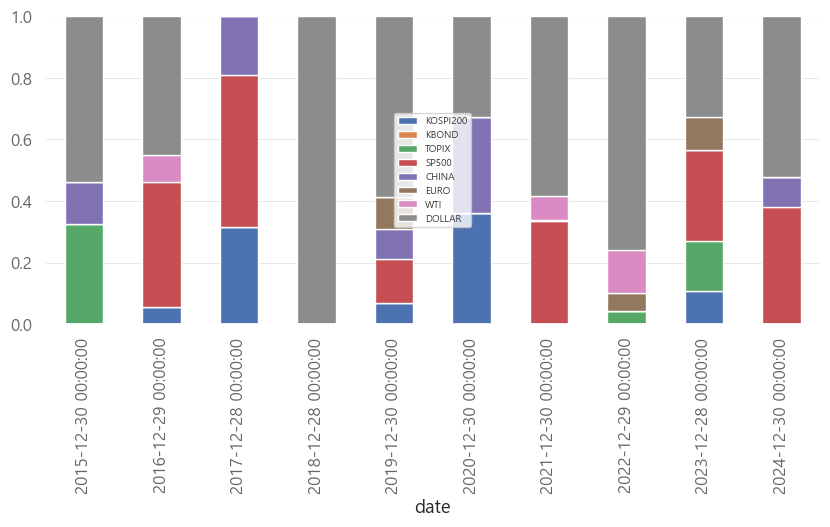

In [10]:
#  연도별 리밸런싱 시점별 투자비중 변화 추이
MVMS_Pw.plot.bar(stacked=True,legend='reverse', figsize=(10,4))
plt.legend(fontsize=7,loc='center')

####  Mean Variance Minimum Volatility = MVP

In [11]:
MVMV_Pw = MeanVarianceMinVolatility(rebal_periods, ret, lookback_periods)
MVMV_idx, _, _ = cal_nav(MVMV_Pw,
                    st_date,
                    ed_date,
                    init,
                    bp,
                    ret.loc[:, MVMV_Pw.columns])
MVMV_idx.name = 'MVP_1 yr'

print(MVMV_Pw.head(3))

            KOSPI200     KBOND  TOPIX     SP500     CHINA  EURO       WTI  \
date                                                                        
2015-12-30  0.073980  0.795121    0.0  0.023513  0.002028   0.0  0.003849   
2016-12-29  0.072425  0.861164    0.0  0.000000  0.000000   0.0  0.000000   
2017-12-28  0.046311  0.860336    0.0  0.028316  0.003225   0.0  0.020117   

              DOLLAR  
date                  
2015-12-30  0.101508  
2016-12-29  0.066411  
2017-12-28  0.041695  


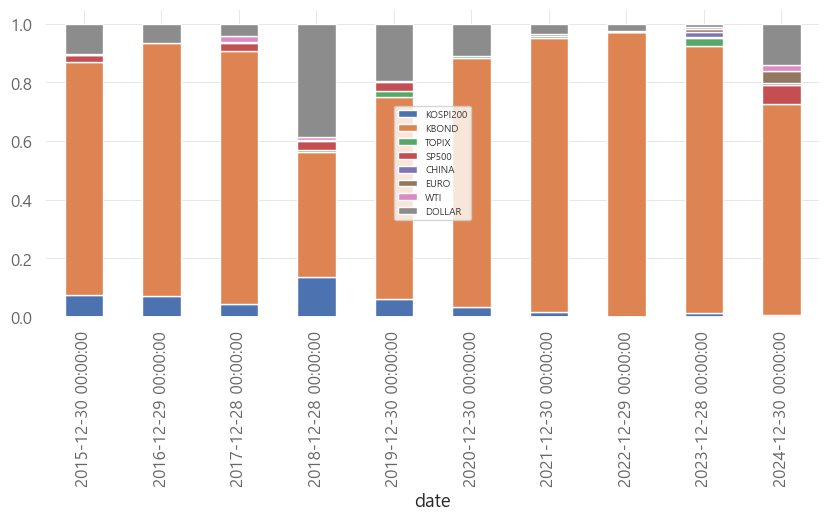

In [12]:
#  연도별 리밸런싱 시점별 투자비중 변화 추이

MVMV_Pw.plot.bar(stacked=True,legend='reverse', figsize=(10,4))
plt.legend(fontsize=7,loc='center')

#### Risk Parity 

In [13]:
RP_Pw = RP(rebal_periods, ret, lookback_periods)
RP_idx, _, _ = cal_nav(RP_Pw,
                    st_date,
                    ed_date,
                    init,
                    bp,
                    ret.loc[:, RP_Pw.columns])

RP_idx.name = 'RP_1yr'

print(RP_Pw.head(3))
print(RP_idx.head(3))

            KOSPI200     KBOND     TOPIX     SP500     CHINA      EURO  \
date                                                                     
2015-12-30  0.089704  0.426656  0.047224  0.064794  0.035523  0.041238   
2016-12-29  0.075110  0.512890  0.026106  0.050478  0.041892  0.032949   
2017-12-28  0.081025  0.502023  0.045199  0.075720  0.058383  0.050291   

                 WTI    DOLLAR  
date                            
2015-12-30  0.046716  0.248146  
2016-12-29  0.029330  0.231245  
2017-12-28  0.049734  0.137625  
date
2016-01-04        100.0
2016-01-05    99.926334
2016-01-06    99.975664
Name: RP_1yr, dtype: object


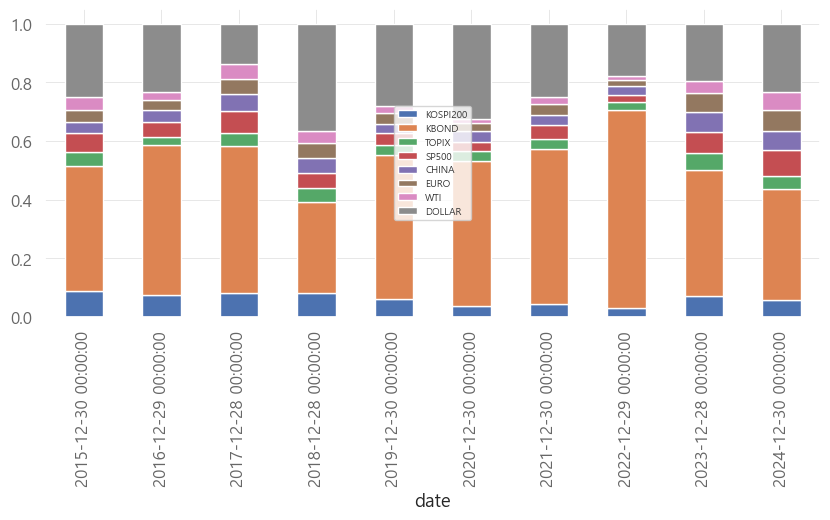

In [14]:
#  연도별 리밸런싱 시점별 투자비중 변화 추이
RP_Pw.plot.bar(stacked=True,legend='reverse', figsize=(10,4))
plt.legend(fontsize=7,loc='center')

####  Maximize Diversification

In [15]:
MD_Pw = MaximizeDiversification(rebal_periods, ret, lookback_periods)
print(MD_Pw.head(5))

            KOSPI200    KBOND    TOPIX    SP500    CHINA     EURO      WTI  \
date                                                                         
2015-12-30   0.12099  0.38114  0.00000  0.03903  0.03862  0.02238  0.06435   
2016-12-29   0.14579  0.46259  0.00000  0.02827  0.02425  0.02071  0.02969   
2017-12-28   0.12339  0.53686  0.00656  0.03554  0.04332  0.02432  0.05962   
2018-12-28   0.15694  0.28070  0.01525  0.03129  0.02709  0.01042  0.03650   
2019-12-30   0.10743  0.48599  0.02634  0.02423  0.01280  0.00465  0.01792   

             DOLLAR  
date                 
2015-12-30  0.33349  
2016-12-29  0.28869  
2017-12-28  0.17039  
2018-12-28  0.44180  
2019-12-30  0.32064  


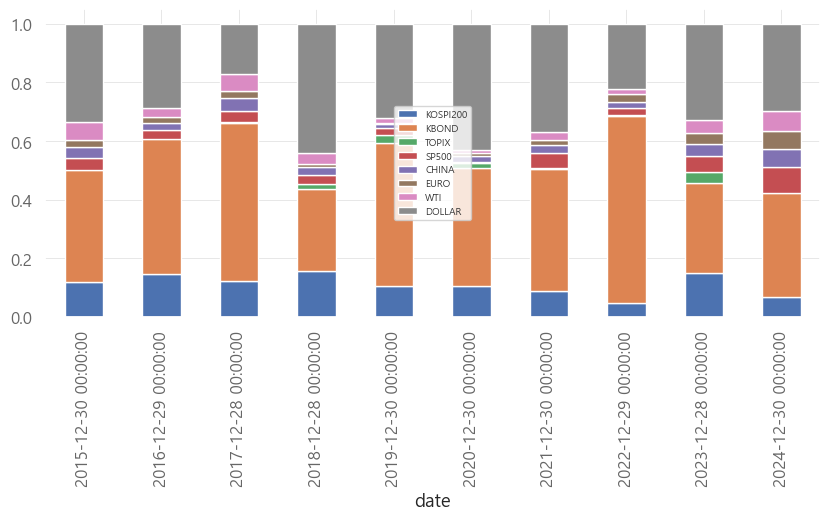

In [16]:
#  연도별 리밸런싱 시점별 투자비중 변화 추이
MD_Pw.plot.bar(stacked=True,legend='reverse', figsize=(10,4))
plt.legend(fontsize=7,loc='center')

In [17]:
MD_idx, _, _ = cal_nav(MD_Pw,
                        st_date,
                        ed_date,
                        init,
                        bp,
                        ret.loc[:, MD_Pw.columns])
MD_idx.name = 'MD_1yr'

##### 자산배분 모형간 성과비교 

In [18]:
ct = pd.concat([MVMS_idx, MVMV_idx,RP_idx, MD_idx], axis=1)

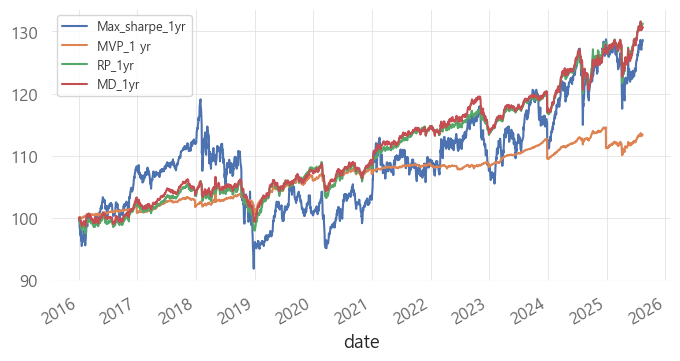

In [19]:
ax=ct.plot(figsize=(8,4))
ax.legend(fontsize=9)
plt.show()

In [20]:
get_summary_pf(ct).sort_values(by='Sharpe ratio', ascending=False)  # 성과 요약표

TypeError: loop of ufunc does not support argument 0 of type float which has no callable rint method